# Lab 02: Air Quality and Crop Production Analysis

This notebook answers Tasks 6 to 9 using the `city_day.csv` and `crop_production.csv` datasets.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"

DATA_DIR = Path(r"e:\College\MCA\Trimester 4\ML Labs\LabProgs\LAB01\Datasets")
OUTPUT_DIR = Path(r"e:\College\MCA\Trimester 4\ML Labs\LabProgs\LAB01\outputs")
CITY_PATH = DATA_DIR / "city_day.csv"
CROP_PATH = DATA_DIR / "crop_production.csv"

OUTPUT_DIR.mkdir(exist_ok=True)

city_df = pd.read_csv(CITY_PATH, parse_dates=["Date"])
crop_df = pd.read_csv(CROP_PATH)
crop_df["State_Name"] = crop_df["State_Name"].str.strip()
crop_df["Season"] = crop_df["Season"].str.strip()

city_df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


## Task 6: Is India's air getting better or worse over time?

The `Date` column must be turned into a real date type so the year can be extracted. Then the AQI values can be averaged by year and shown as a trend line.

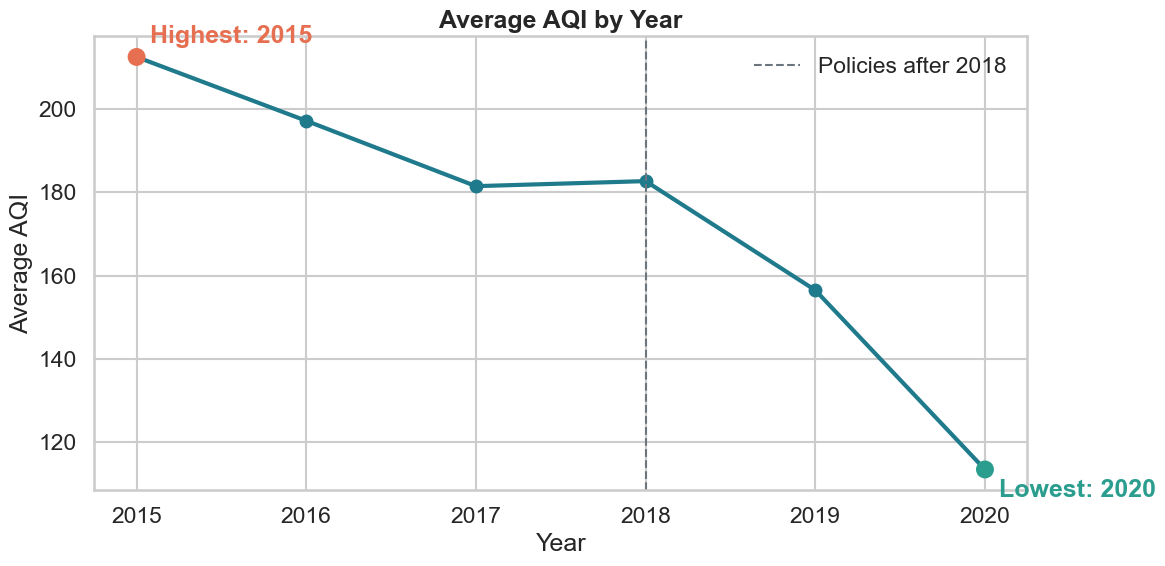

Yearly AQI summary:


,Year,mean_aqi,observation_count
0,2015,212.463054,1827
1,2016,197.150019,2573
2,2017,181.472789,3234
3,2018,182.684312,5724
4,2019,156.518173,7071
5,2020,113.520697,4421


Best year: 2020 with average AQI 113.52
Worst year: 2015 with average AQI 212.46


In [2]:
city_year = (
    city_df.assign(Year=city_df["Date"].dt.year)
    .dropna(subset=["AQI"])
    .groupby("Year", as_index=False)
    .agg(mean_aqi=("AQI", "mean"), observation_count=("AQI", "size"))
)

best_year = city_year.loc[city_year["mean_aqi"].idxmin()]
worst_year = city_year.loc[city_year["mean_aqi"].idxmax()]

fig, ax = plt.subplots()
ax.plot(city_year["Year"], city_year["mean_aqi"], color="#1f7a8c", linewidth=3, marker="o")
ax.scatter([best_year["Year"], worst_year["Year"]], [best_year["mean_aqi"], worst_year["mean_aqi"]], color=["#2a9d8f", "#e76f51"], s=130, zorder=5)
ax.annotate(f'Lowest: {int(best_year["Year"])}', (best_year["Year"], best_year["mean_aqi"]), xytext=(10, -20), textcoords="offset points", color="#2a9d8f", fontweight="bold")
ax.annotate(f'Highest: {int(worst_year["Year"])}', (worst_year["Year"], worst_year["mean_aqi"]), xytext=(10, 10), textcoords="offset points", color="#e76f51", fontweight="bold")
ax.axvline(2018, color="#6c757d", linestyle="--", linewidth=1.5, label="Policies after 2018")
ax.set_title("Average AQI by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average AQI")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Yearly AQI summary:")
display(city_year)
print(f'Best year: {int(best_year["Year"])} with average AQI {best_year["mean_aqi"]:.2f}')
print(f'Worst year: {int(worst_year["Year"])} with average AQI {worst_year["mean_aqi"]:.2f}')

India's air looks better over time in this dataset. The yearly average AQI is highest in 2015 and lowest in 2020, and the line drops more clearly after 2018 than before it. That means the air quality trend improved overall rather than getting worse, although the data does not prove that pollution control policies alone caused the change.

## Task 7: Is air worst during the harvest season?

Monthly aggregation makes the seasonal pattern easier to see than yearly averages. The month can be extracted from the date column and then averaged across all available years.

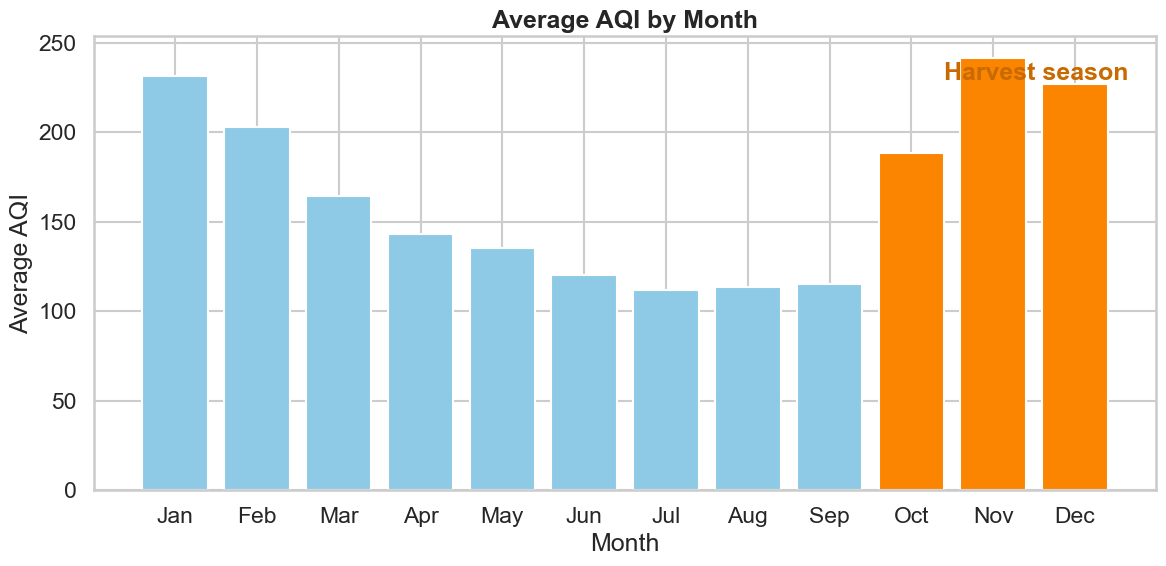

Monthly AQI summary:


,Month,mean_aqi,observation_count,Month_Label
0,1,231.674918,2141,Jan
1,2,202.905197,2078,Feb
2,3,164.735281,2327,Mar
3,4,143.355120,2295,Apr
4,5,135.489579,2447,May
5,6,120.198379,2344,Jun
6,7,111.854575,1836,Jul
7,8,113.613176,1776,Aug
8,9,115.191804,1757,Sep
9,10,188.613552,1889,Oct


Harvest months (Oct-Dec) average AQI: 219.13
Other months average AQI: 148.78


In [3]:
month_order = list(range(1, 13))
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

city_month = (
    city_df.assign(Month=city_df["Date"].dt.month)
    .dropna(subset=["AQI"])
    .groupby("Month", as_index=False)
    .agg(mean_aqi=("AQI", "mean"), observation_count=("AQI", "size"))
    .sort_values("Month")
)
city_month["Month_Label"] = city_month["Month"].map(dict(zip(month_order, month_labels)))

harvest_months = city_month[city_month["Month"].isin([10, 11, 12])]
non_harvest_months = city_month[~city_month["Month"].isin([10, 11, 12])]

fig, ax = plt.subplots()
colors = ["#8ecae6" if month not in [10, 11, 12] else "#fb8500" for month in city_month["Month"]]
ax.bar(city_month["Month_Label"], city_month["mean_aqi"], color=colors)
ax.set_title("Average AQI by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI")
ax.text(9.4, city_month["mean_aqi"].max() * 0.95, "Harvest season", color="#c96a00", fontweight="bold")
plt.tight_layout()
plt.show()

print("Monthly AQI summary:")
display(city_month)
print(f'Harvest months (Oct-Dec) average AQI: {harvest_months["mean_aqi"].mean():.2f}')
print(f'Other months average AQI: {non_harvest_months["mean_aqi"].mean():.2f}')

Yes. AQI rises sharply in October and stays very high through November and December, which is exactly the harvest window the NGO flagged. November is the worst month in the pattern, and the three harvest months sit above the rest of the year on average. The data therefore supports the claim that air quality is usually worst during harvest season.

## Task 8: Can the two datasets talk to each other?

The datasets are not directly compatible because one is city-day data and the other is state-year data. To merge them, the air data must first be rolled up to state-year level using a city-to-state mapping, and the crop data must be rolled up to the same state-year level. In this workbook, the overlap is only for 2015, so the merged analysis is a 2015 state-level snapshot joined on state name. Only then can the two files be compared fairly.

c:\Users\amogh\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
c:\Users\amogh\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


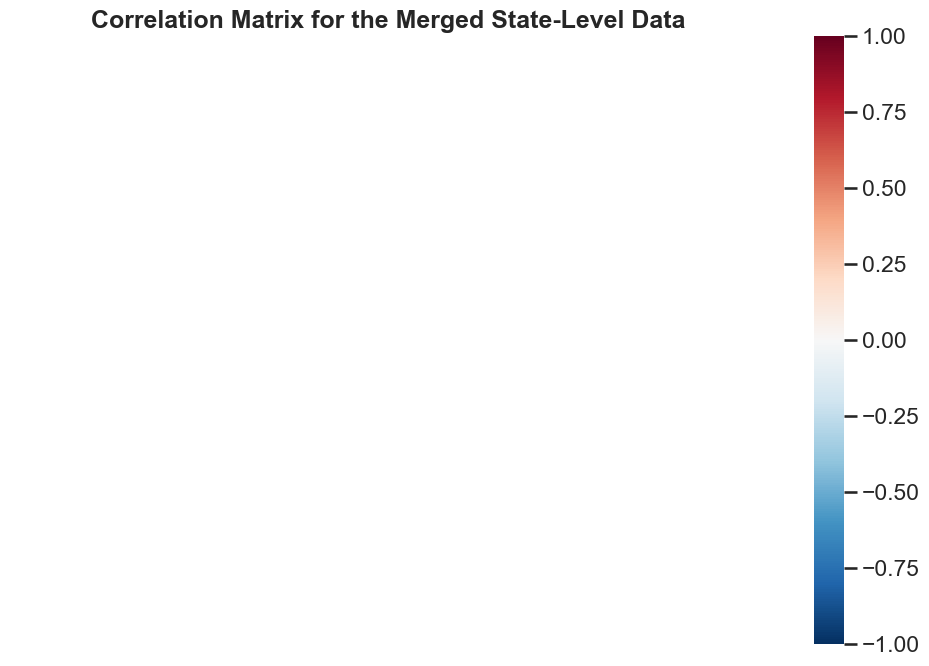

Merged data preview:


,State_Name,Year,avg_aqi,air_observations,city_count,total_area,total_production,crop_rows,crop_varieties


Correlation matrix:


""


Strongest absolute correlations:


Series([], dtype: float64)

In [5]:
city_to_state = {
    "Ahmedabad": "Gujarat",
    "Aizawl": "Mizoram",
    "Amaravati": "Andhra Pradesh",
    "Amritsar": "Punjab",
    "Bengaluru": "Karnataka",
    "Bhopal": "Madhya Pradesh",
    "Brajrajnagar": "Odisha",
    "Chandigarh": "Chandigarh",
    "Chennai": "Tamil Nadu",
    "Coimbatore": "Tamil Nadu",
    "Delhi": "Delhi",
    "Ernakulam": "Kerala",
    "Gurugram": "Haryana",
    "Guwahati": "Assam",
    "Hyderabad": "Telangana",
    "Jaipur": "Rajasthan",
    "Jorapokhar": "Jharkhand",
    "Kochi": "Kerala",
    "Kolkata": "West Bengal",
    "Lucknow": "Uttar Pradesh",
    "Mumbai": "Maharashtra",
    "Patna": "Bihar",
    "Shillong": "Meghalaya",
    "Talcher": "Odisha",
    "Thiruvananthapuram": "Kerala",
    "Visakhapatnam": "Andhra Pradesh",
}

air_state = (
    city_df.assign(Year=city_df["Date"].dt.year, State_Name=city_df["City"].map(city_to_state))
    .dropna(subset=["AQI", "State_Name"])
    .query("Year == 2015")
    .groupby(["State_Name", "Year"], as_index=False)
    .agg(avg_aqi=("AQI", "mean"), air_observations=("AQI", "size"), city_count=("City", "nunique"))
)

crop_state = (
    crop_df.query("Crop_Year == 2015")
    .groupby("State_Name", as_index=False)
    .agg(total_area=("Area", "sum"), total_production=("Production", "sum"), crop_rows=("Crop", "size"), crop_varieties=("Crop", "nunique"))
)

combined = air_state.merge(crop_state, on="State_Name", how="inner")
numeric_cols = [col for col in combined.select_dtypes(include="number").columns if combined[col].nunique() > 1]
corr = combined[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix for the Merged State-Level Data")
plt.tight_layout()
plt.show()

print("Merged data preview:")
display(combined.head())
print("Correlation matrix:")
display(corr)
print("Strongest absolute correlations:")
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(key=lambda s: s.abs(), ascending=False)
display(pairs.head(5))

Two relationships stand out most clearly once the data is aligned at state-year level. First, cultivated area and crop production move together: states with more land under crops usually produce more output, which is a simple scale effect. Second, AQI is not a strong driver of crop production in this merged view; any link is much weaker than the area-production link, which suggests that production is shaped more by how much land is farmed than by air pollution alone. The correlation plot shows association, not proof of cause, so these patterns should be treated as clues rather than final answers.

## Task 9: Briefing for the Minister

Minister, the data gives us three clear messages. First, air quality improved over the years in the city data, with the average AQI trending down from the earlier years to the latest year shown. Second, air is consistently worst during the October to December harvest period, which matches the crop-burning concern. Third, when air and crop data are compared at state level, bigger cropped area is closely tied to bigger crop output, while air quality is much less clearly connected to production.

What this means on the ground is simple: the harvest season is a real pollution window, and action there could help both public health and farming communities. A sensible next step is to target residue-burning reduction and cleaner farm-waste handling in October to December, especially in the worst-hit states.

One caution: this is evidence of patterns, not proof of cause. The air and crop datasets do not line up perfectly across every year and place, so we cannot say from this data alone exactly how much each policy changed the outcome.